# Moment-Curvature

A moment-curvature analysis is performed using a uniaxial fiber section.

The geometry of the section is depicted below:

![](/_static/images/gallery/fiber-0004-46f03605.png)

## Materials

In [2]:

import xara
from xara.units.iks import inch, foot, ksi, kip 

Fy = 60*ksi
Es = 29e3*ksi

# Define materials
materials = {
    "core": xara.UniaxialMaterial(
        type = "Concrete01",
        Fc  =  6*ksi,
        nu  =  0.2,
        ec0 =  0.004,
        Fcu =  5*ksi,
        ecu =  0.014
    ),
    "cover": xara.UniaxialMaterial(
        type = "Concrete01",
        Fc  =  -5*ksi,
        nu  =   0.2,
        ec0 =  -0.002,
        Fcu =  -0.0*ksi,
        ecu =  -0.006,
        # "lambda": 0.1,
        # "Ft": 0.65*ksi,
        # "Ets": 500. # Tension stiffening
    ),
    "rebar": xara.UniaxialMaterial(
        type = "Steel01",
        nu = 0.3,
        E  =   29e3*ksi,
        Fy =     60*ksi,
        b =   0.01
    )
}


## Geometry

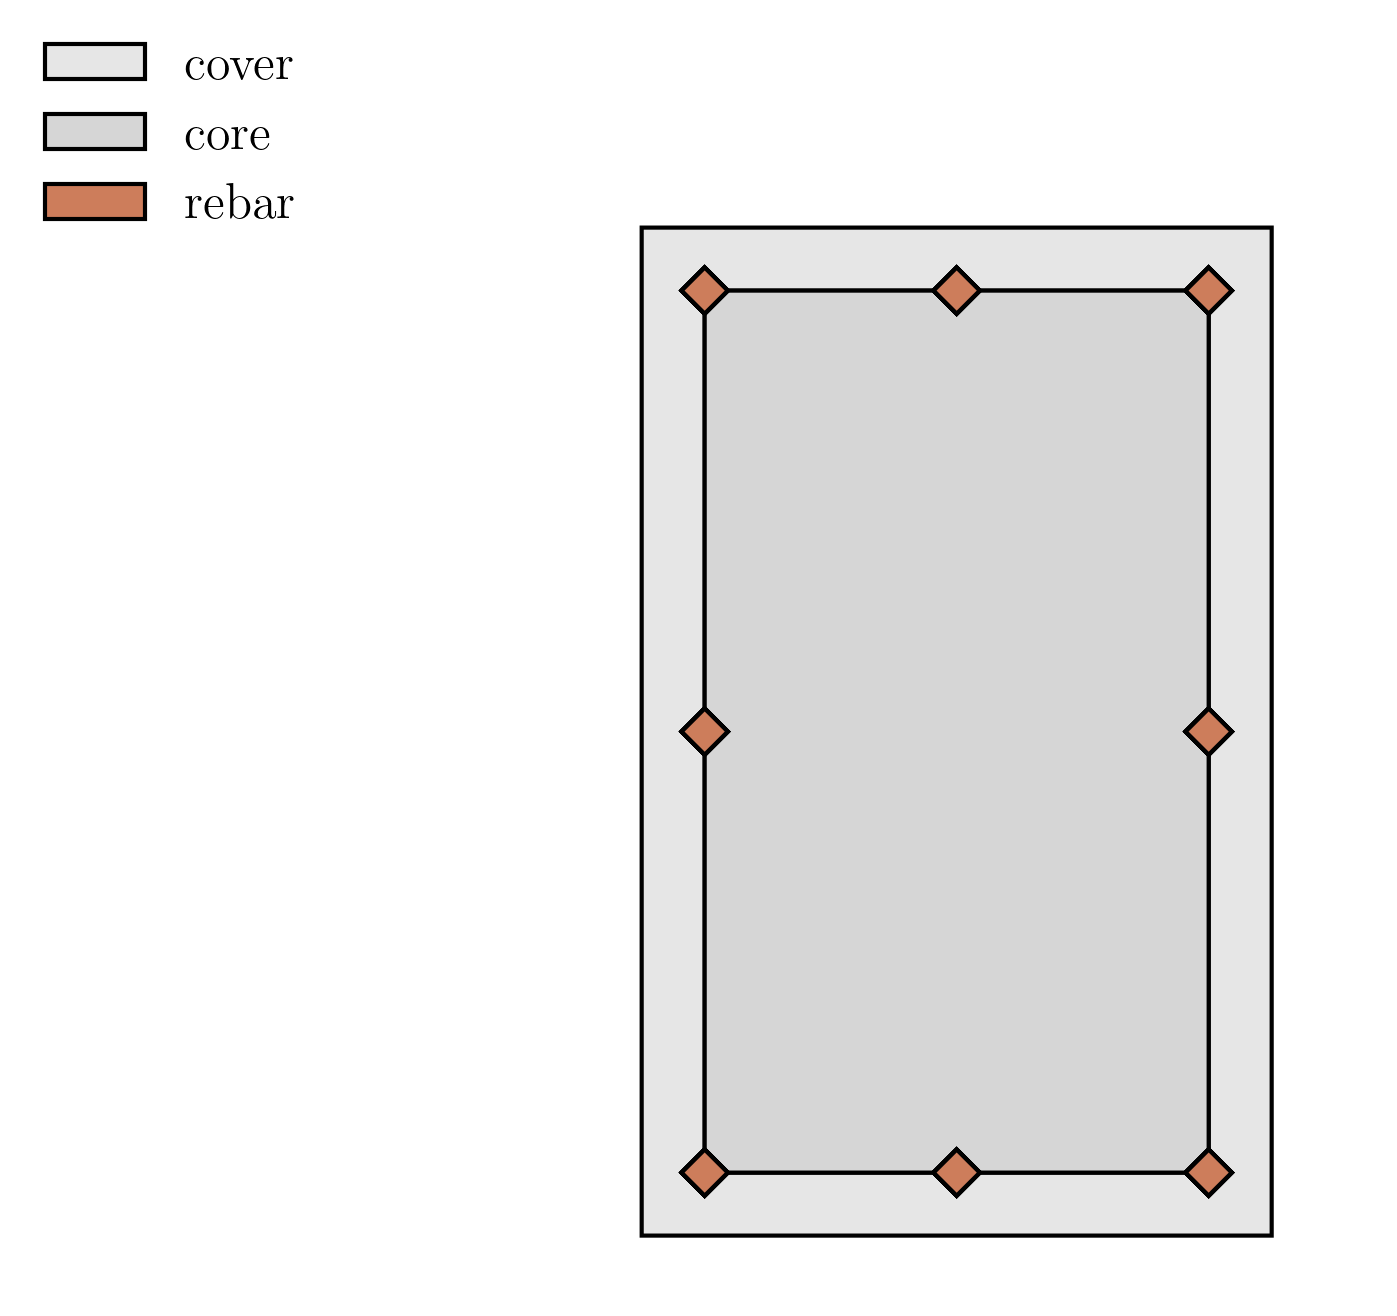

In [3]:
import veux
from xsection import CompositeSection
from xsection.library import Circle, Rectangle
import matplotlib.pyplot as plt


# dimensions
b = width = 15.0*inch
h = depth = 24.0*inch
c = cover =  1.5*inch

As = 0.60*inch**2;        # area of no. 7 bars
r_bar = (7/16)*inch;      # radius of rebar

bar = Circle(radius=r_bar, 
             z=2, 
             material=materials["rebar"], 
             group="rebar", 
             divisions=4, 
             mesh_scale=1/2)

# some variables derived from the parameters
y1 = depth/2.0
z1 = width/2.0

shape = CompositeSection([
    Rectangle(    b, h,     z=0, group="cover", material=materials["cover"]),
    Rectangle(b-2*c, h-2*c, z=1, group="core",  material=materials["core"]),
    *bar.linspace([-b/2+c, -h/2+c], [ b/2-c,-h/2+c], 3), # Top bars
    *bar.linspace([-b/2+c,      0], [ b/2-c,     0], 2), # Center bars
    *bar.linspace([-b/2+c,  h/2-c], [ b/2-c, h/2-c], 3)  # Bottom bars
])


veux.draw_shape(shape)

In [5]:

section = xara.FrameSection("UniaxialFiber", shape)

## Model

A {ref}`ZeroLengthSection <zeroLengthSection>` element is used.

In [6]:
def create_model(section, y=None):
    model = xara.Model(ndm=3, ndf=6)

    # Define two nodes at (0,0)
    model.node(1, (0.0, 0.0, 0))
    model.node(2, (0.0, 0.0, 0))

    # Fix all degrees of freedom except axial and bending
    model.fix(1, (1, 1, 1, 1, 1, 1))
    model.fix(2, (0, 1, 1, 1, 0, 1))

    # Define materials
    for material in materials.values():
        model.material(material)

    # Define section
    model.section(section)

    # Define element
    x = (1.0, 0.0, 0.0)
    if y is None:
        y = (0.0, 1.0, 0.0)
    model.element("ZeroLengthSection", 1, (1, 2), section, y=y, x=x)

    return model


## Analysis

In [7]:
import numpy as np

def moment_curvature(section, axialLoad, maxK, numIncr, y=None):
    """
    Arguments
       section -- section to be analyzed
       axialLoad -- axial load applied to section (negative is compression)
       maxK -- maximum curvature reached during analysis
       numIncr -- number of increments used to reach maxK (default 100)
    """
    model = create_model(section, y=y)
    #
    # Apply axial loading
    #

    # Define constant axial load
    model.pattern("Plain", 1, "Constant", 
                  loads={2: [axialLoad, 0.0, 0.0, 0, 0, 0]}
    )

    analysis_A = xara.StaticAnalysis(model,
        integrator=xara.LoadFactorControl("Proportional", 0.0),
        algorithm="Newton",
        test=xara.Test("NormUnbalance", 1.0e-10, 10)
    )

    # Do one analysis for constant axial load
    analysis_A.analyze(1)

    #
    # Analyze in flexure
    #
    # Define reference moment
    model.pattern("Plain", 2, "Linear")
    model.load(2, (0, 0, 0, 0.0, 1.0, 0.0), pattern=2)

    # Compute curvature increment
    dK = maxK/numIncr


    # Use displacement control at node 2 for section analysis
    analysis = xara.StaticAnalysis(model,
        integrator=xara.LoadFactorControl("DisplacementControl", 2, 5, dK),
        algorithm="Newton",
        test=xara.Test("NormUnbalance", 1.0e-10, 10)
    )

    # Do the section analysis
    M,K = [0], [0]
    for i in range(numIncr):
        status = analysis.analyze(1)
        if status != 0:
            print(f"Analysis failed at step {i}")
            break
        else:
            K.append(model.nodeDisp(2, 5))
            M.append(model.getTime())

    return np.array([K,M])



In [8]:

P   =  -180.0   # Axial load
mu  =    32.0   # Target ductility for analysis
numIncr = 200   # Number of analysis increments


# Estimate yield curvature
# (Assuming no axial load and only top and bottom steel)
d = depth - cover   # d -- from cover to rebar
epsy = Fy/Es # steel yield strain
Ky = epsy/(0.7*d)
Kz = epsy/(0.7*b)


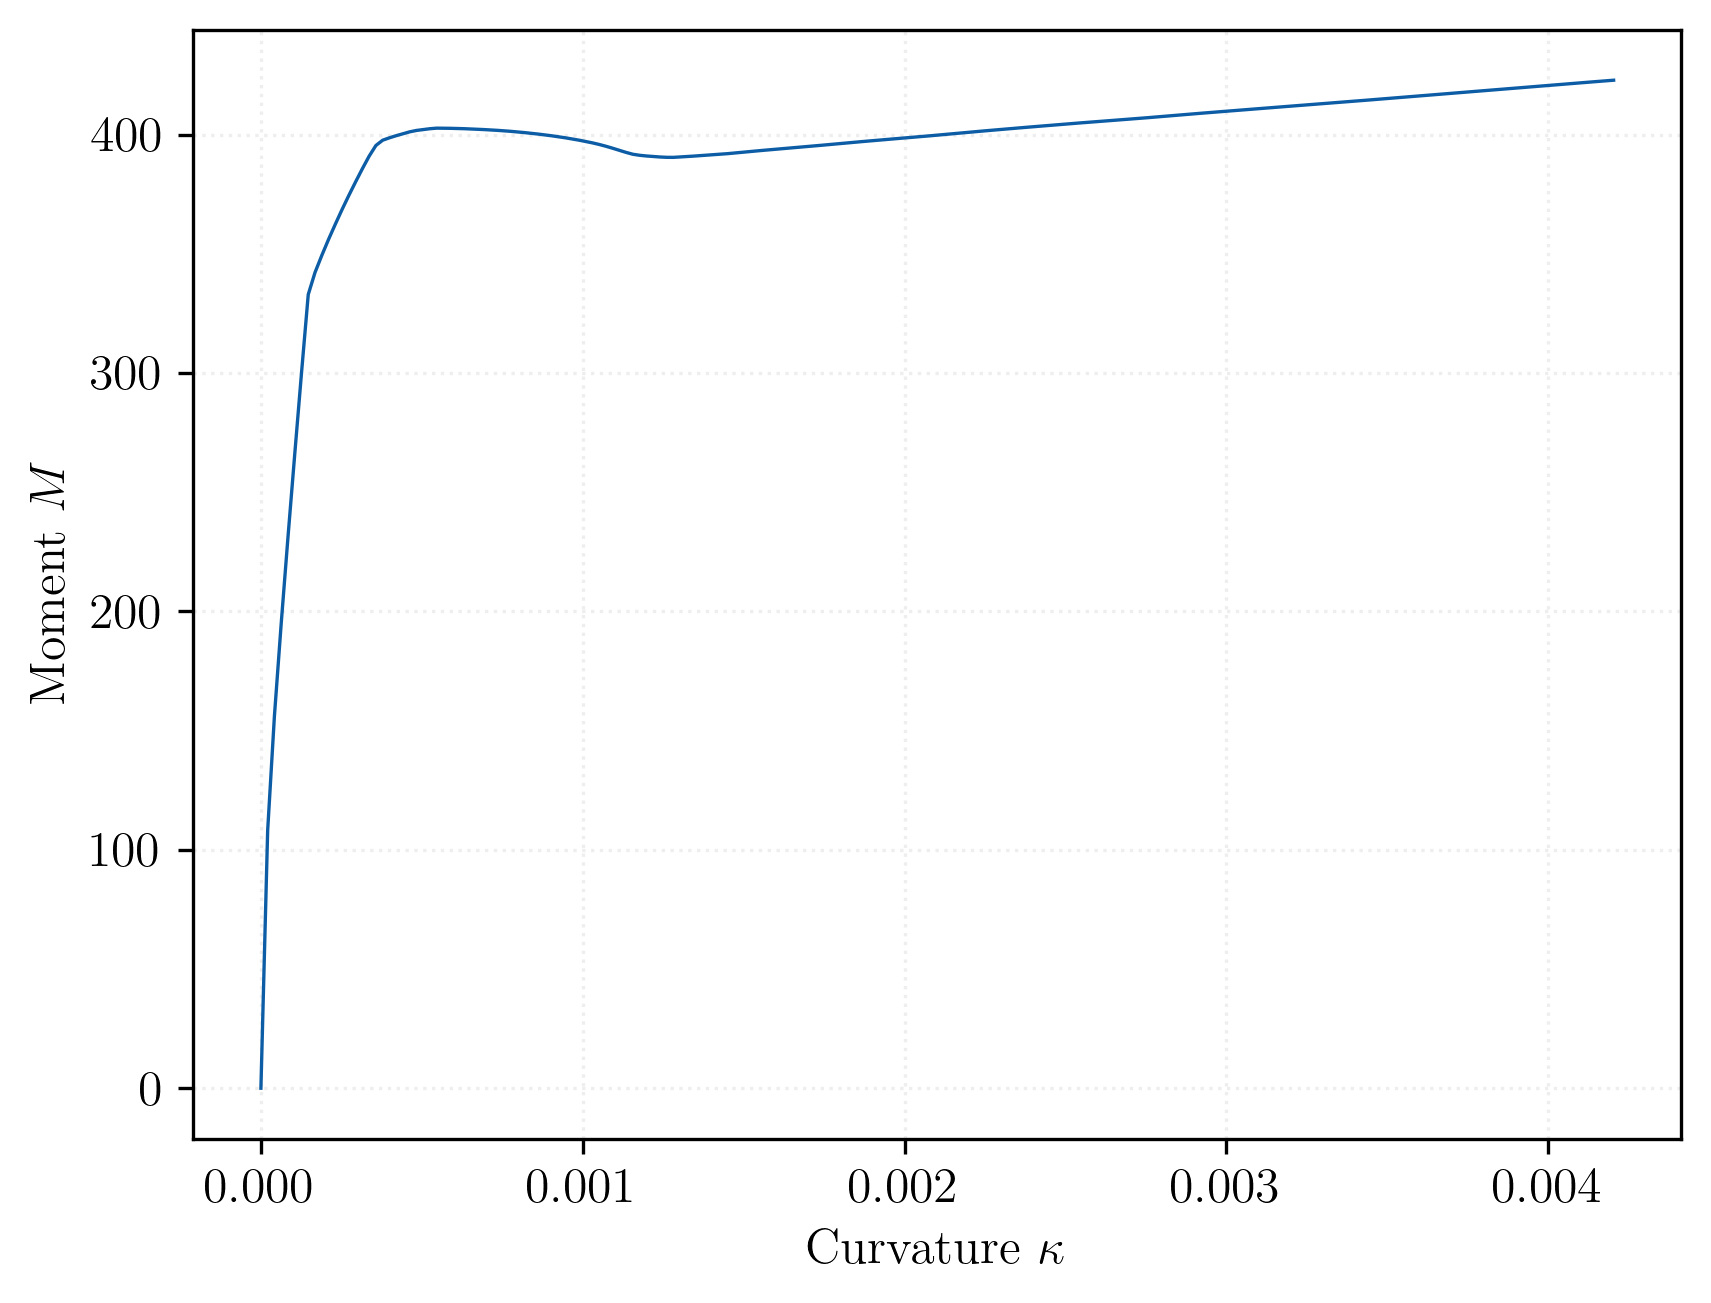

In [9]:

K, M = moment_curvature(section, P, Ky*mu, numIncr)
plt.plot(K, M/(kip*foot))
plt.grid(True)
plt.xlabel("Curvature $\\kappa$")
plt.ylabel("Moment $M$");